In [ ]:
import os
import numpy as np
import plotly.graph_objects as go

# --- Updated signal function ---
def signal(data, samples, first='reference'):
    data_shape = data.shape[0]
    steps = int(data_shape / (2 * samples))

    if first.lower() == 'reference':
        reference_samples = np.mean(np.reshape(data[::2], (steps, samples)), axis=1)
        signal_samples = np.mean(np.reshape(data[1::2], (steps, samples)), axis=1)
    elif first.lower() == 'signal':
        signal_samples = np.mean(np.reshape(data[::2], (steps, samples)), axis=1)
        reference_samples = np.mean(np.reshape(data[1::2], (steps, samples)), axis=1)
    else:
        raise ValueError("`first` must be either 'reference' or 'signal'")

    signal_photon = signal_samples / reference_samples
    return signal_photon, reference_samples, signal_samples

# --- Wrapper function ---
def data_to_time_signal(data, samples, first='reference'):
    time = data['time_axis']
    signal_photon, reference_samples, signal_samples = signal(data['avg_data'], samples, first=first)
    return time, signal_photon, reference_samples, signal_samples

# --- Custom Plotly Template ---
fig_template = go.layout.Template()
fig_template.layout = {
    'template': 'simple_white+presentation',
    'autosize': False,
    'width': 800,
    'height': 600,
    'xaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white',
    },
    'yaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white'
    },
    'font': {
        'family': 'mathjax',
        'size': 22,
    }
}
power = 8

# --- Base path ---
base_path = rf"C:\Users\Atanu\OneDrive\Desktop\research_work\paper\T1_atanu_github\T1_measurements\codes\data\2025\May_12\arranging_datas_with_power\{power}uW"


# --- Power folders ---
power_folders = ['l_15.0us', 'l_25.0us', 'l_50.0us', 'l_100.0us']

# --- Initialize figure ---
fig = go.Figure()

# --- Process each power folder ---
for folder in power_folders:
    folder_path = os.path.join(base_path, folder)
    npz_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.npz')])
    
    if len(npz_files) < 3:
        print(f"Less than 3 datasets found in {folder_path}. Skipping.")
        continue

    signal_photon_list = []
    time_axis = None
    

    for npz_file in npz_files[:-1]:  # Limit to 3 datasets
        npz_path = os.path.join(folder_path, npz_file)
        data = dict(np.load(npz_path))
        time_axis, signal_photon, _, _ = data_to_time_signal(data, 2000, first='signal')
        signal_photon_list.append(signal_photon[1:])  # skip the first element

    # Convert list to 2D array (shape: 3 x N)
    signal_array = np.vstack(signal_photon_list)

    # Calculate mean and std deviation
    mean_signal = np.mean(signal_array, axis=0)
    std_signal = np.std(signal_array, axis=0)

    fig.add_trace(go.Scatter(
        x=time_axis[1:],  # skip the first point
        y=mean_signal,
        mode='markers',
        name=f'{folder}',
        error_y=dict(
            type='data',
            array=std_signal,
            visible=True
        )
    ))

# --- Final layout ---
fig.update_layout(
    template=fig_template,
    title=f'Signal Photon vs Time for {power}uW Initialization',
    xaxis_title='Time',
    yaxis_title='Counts (T<sub>1</sub>)'
)

# --- Show and Save ---
fig.show()

html_output_path = os.path.join(base_path, f"signal_vs_time_plot_with_errorbars_{power}uW.html")
fig.write_html(html_output_path)
print(f"Plot successfully saved to: {html_output_path}")



Processing: first cluster


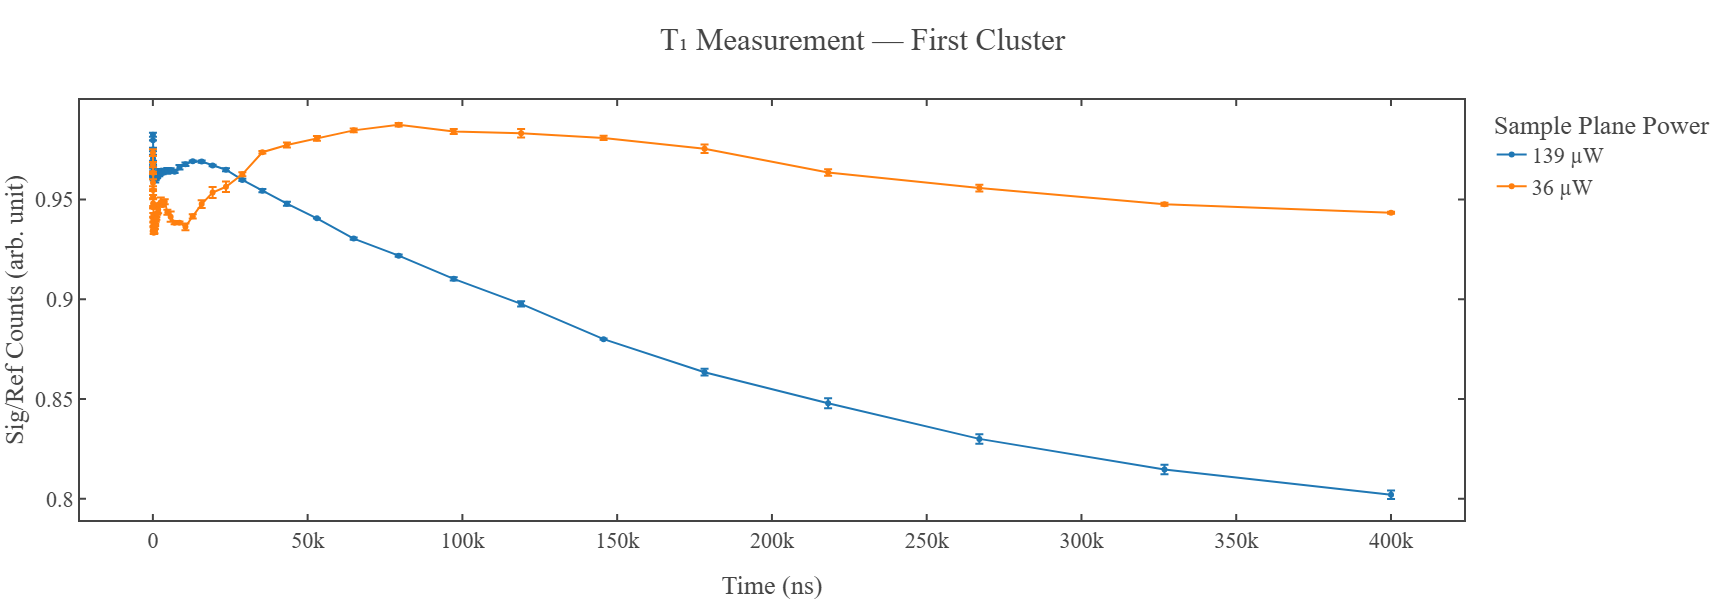

Plot saved to: C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10\first cluster\t1_plot_first_cluster_139uW_36uW.html

Processing: second cluster


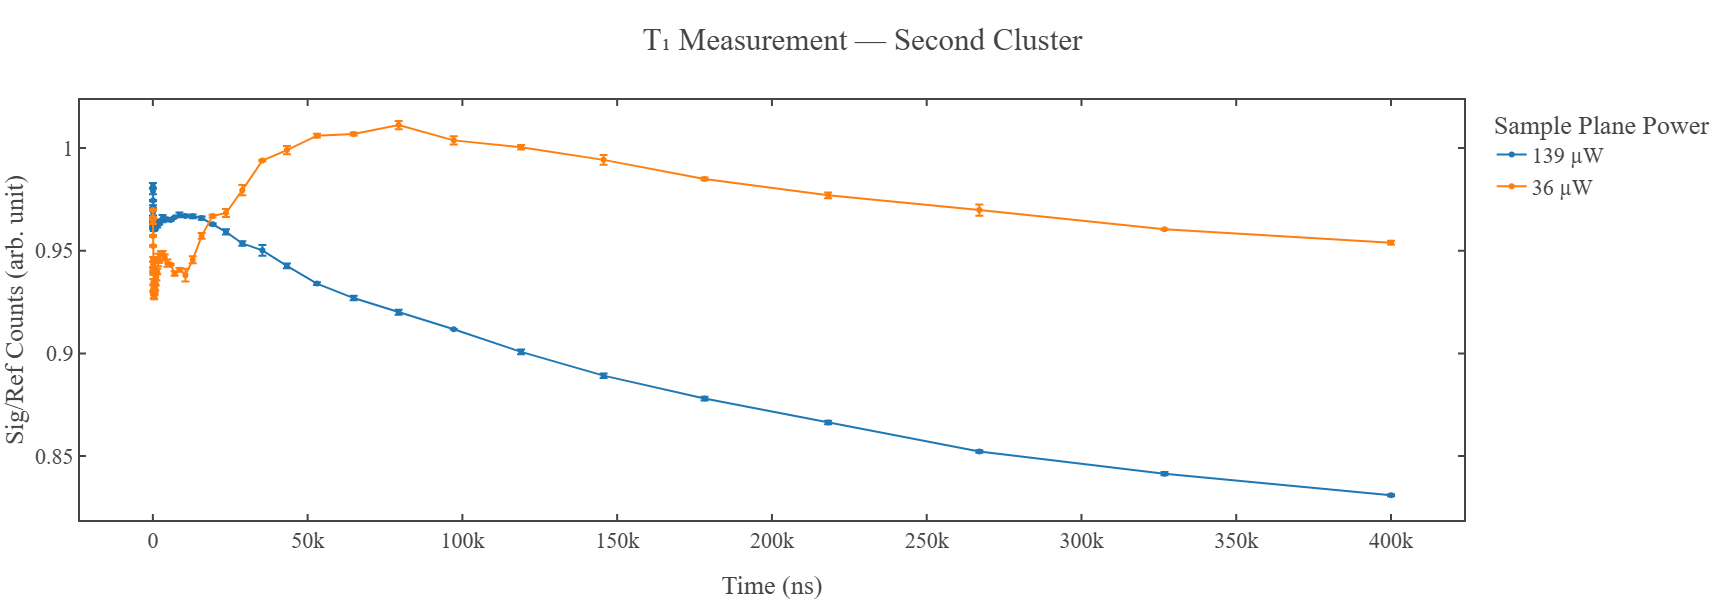

Plot saved to: C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10\second cluster\t1_plot_second_cluster_139uW_36uW.html

Processing: third cluster


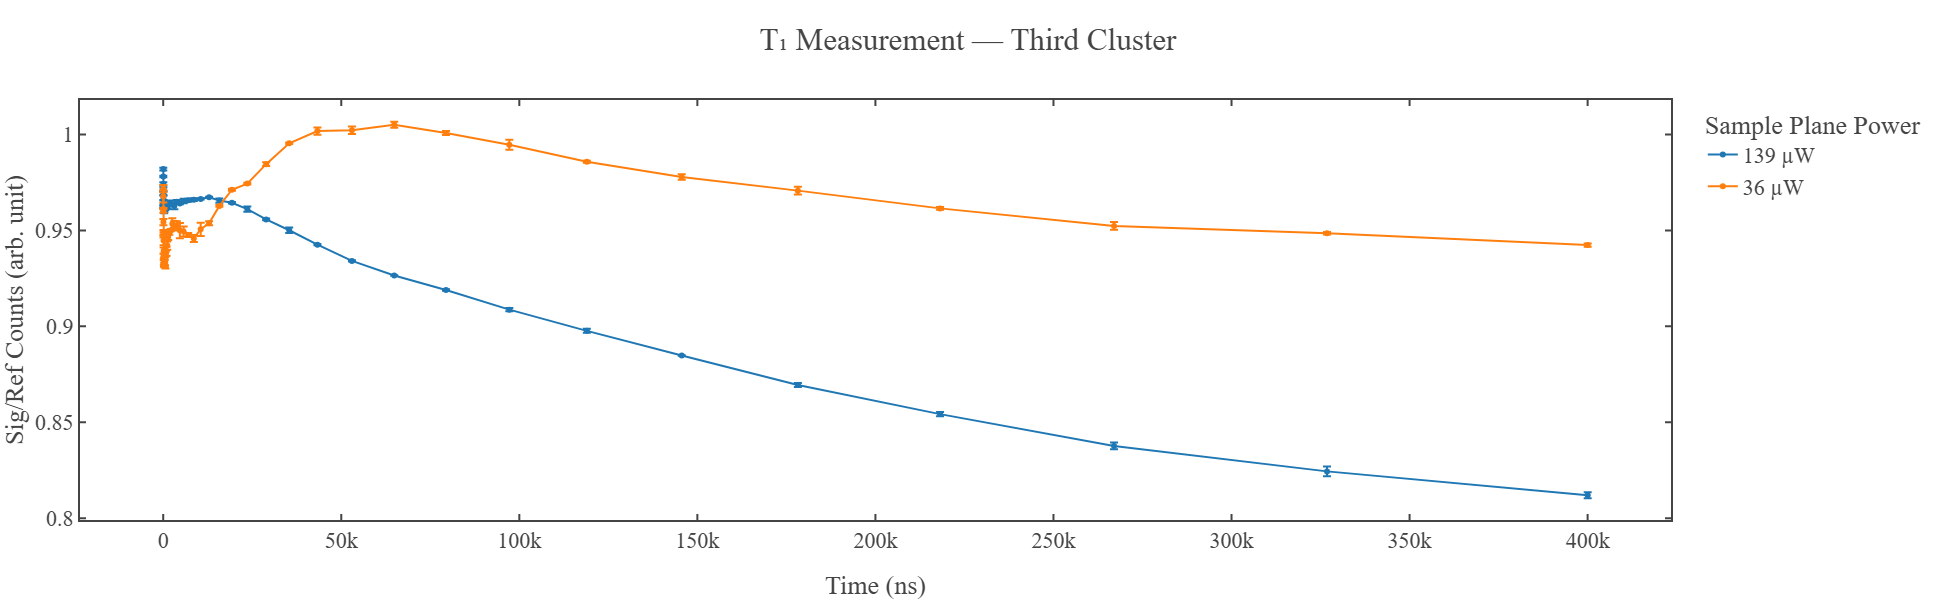

Plot saved to: C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10\third cluster\t1_plot_third_cluster_139uW_36uW.html

Processing: fourth cluster


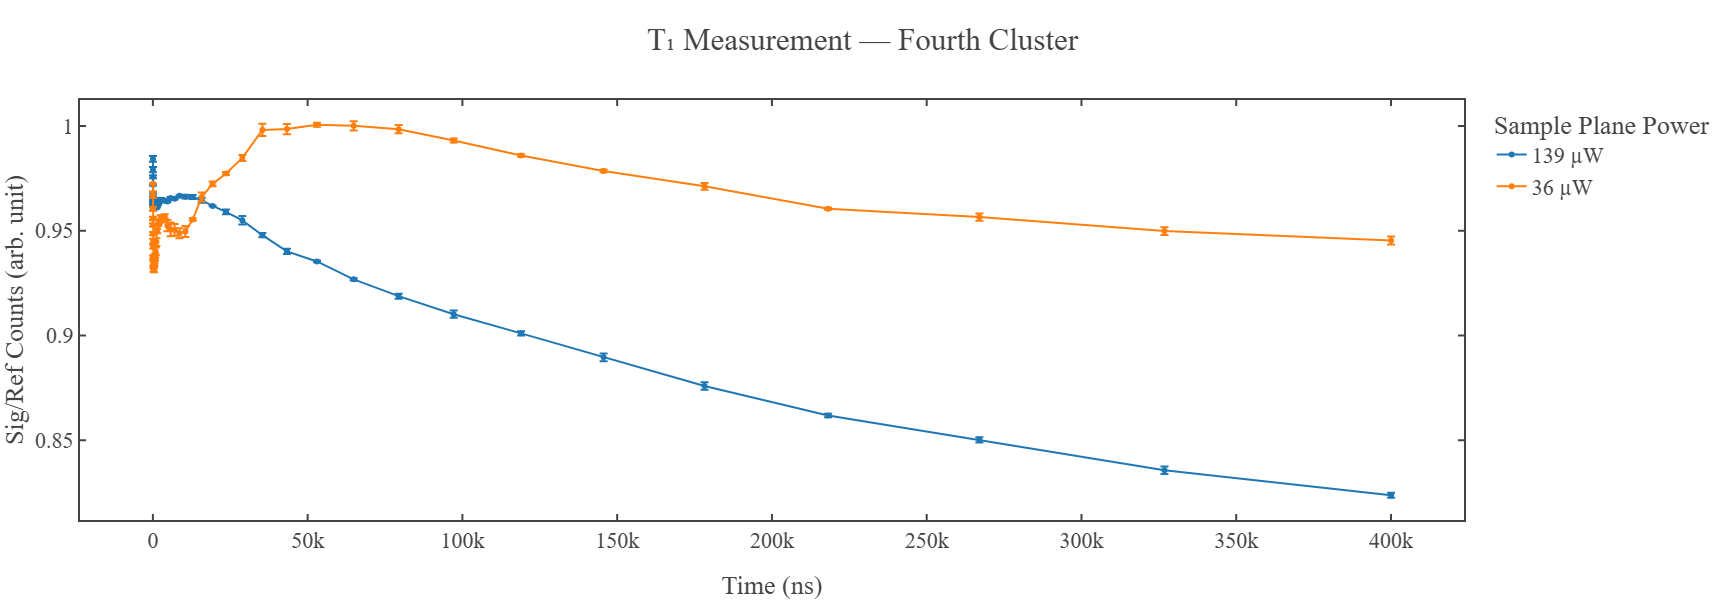

Plot saved to: C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10\fourth cluster\t1_plot_fourth_cluster_139uW_36uW.html

Processing: fifth cluster


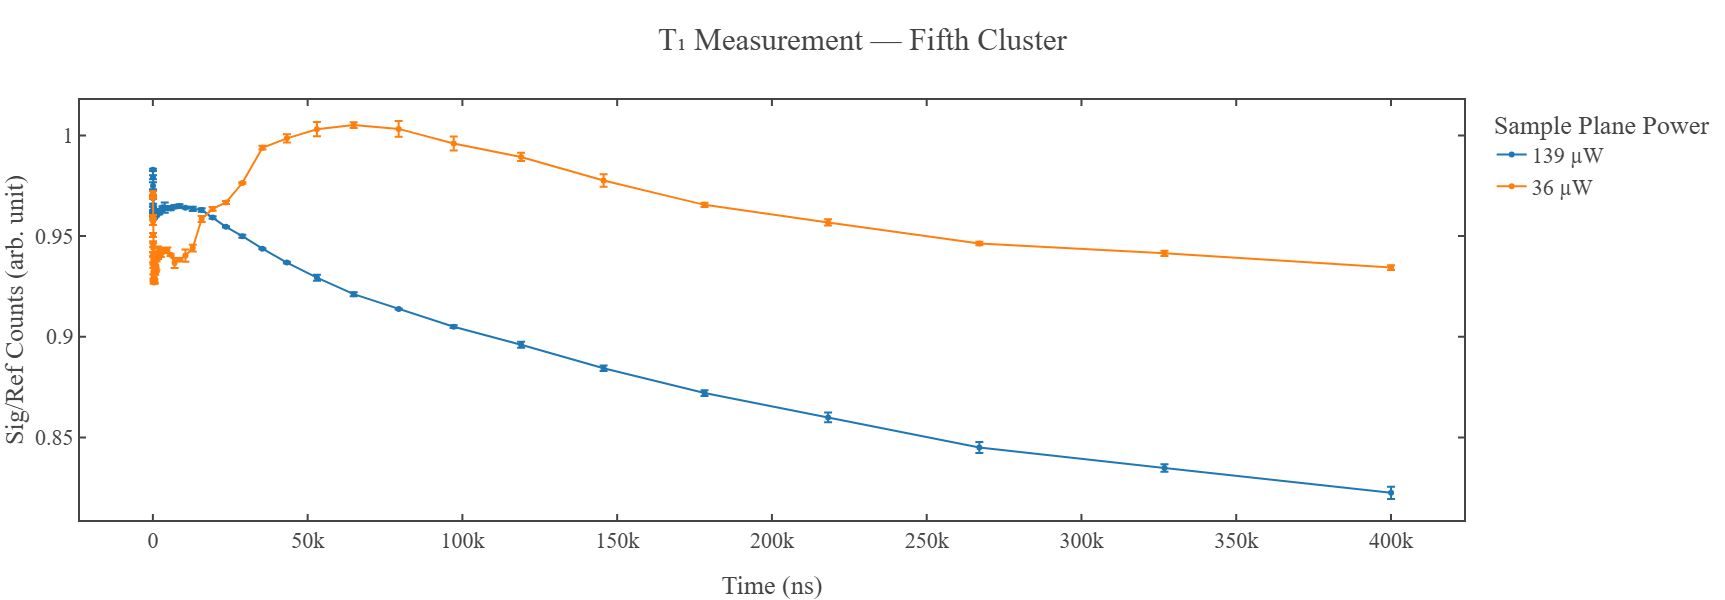

Plot saved to: C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10\fifth cluster\t1_plot_fifth_cluster_139uW_36uW.html


In [61]:
import os
import numpy as np
import plotly.graph_objects as go

# --- Signal Processing Function ---
def signal(data, samples, first='reference'):
    data_shape = data.shape[0]
    steps = int(data_shape / (2 * samples))

    if first.lower() == 'reference':
        reference_samples = np.mean(np.reshape(data[::2], (steps, samples)), axis=1)
        signal_samples = np.mean(np.reshape(data[1::2], (steps, samples)), axis=1)
    elif first.lower() == 'signal':
        signal_samples = np.mean(np.reshape(data[::2], (steps, samples)), axis=1)
        reference_samples = np.mean(np.reshape(data[1::2], (steps, samples)), axis=1)
    else:
        raise ValueError("`first` must be either 'reference' or 'signal'")

    signal_photon = signal_samples / reference_samples
    return signal_photon, reference_samples, signal_samples

# --- Wrapper to Process NPZ ---
def data_to_time_signal(data, samples, first='reference'):
    time = data['time_axis']
    signal_photon, reference_samples, signal_samples = signal(data['avg_data'], samples, first=first)
    return time, signal_photon, reference_samples, signal_samples

# --- Plotly Template ---
fig_template = go.layout.Template()
fig_template.layout = {
    'template': 'simple_white+presentation',
    'autosize': False,
    'width': 800,
    'height': 600,
    'xaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white',
    },
    'yaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white'
    },
    'font': {
        'family': 'mathjax',
        'size': 22,
    }
}

# --- Calibration Dictionary (source mW → sample µW) ---
calibration = {
    1: 13,
    3: 36,
    4: 47,
    5: 64,
    7: 79,
    9: 104,
    11: 139,
    13: 167,
    15: 191,
    17: 209,
    18: 221
}

# --- Parameters ---
samples = 2000
base_folder_root = r"C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10"
pulse_folder = "l_50.0us"
systematic_path = r"systematic\a_5\s_2000"
cluster_folders = ['first cluster', 'second cluster', 'third cluster', 'fourth cluster', 'fifth cluster']
power_folders = ['p_11mW', 'p_3mW']

# --- Loop through each cluster ---
for cluster_name in cluster_folders:
    print(f"\nProcessing: {cluster_name}")
    
    # --- Initialize a new figure for each cluster ---
    fig = go.Figure()

    for power_folder in power_folders:
        # Extract numeric source power (e.g., "11" from "p_11mW")
        try:
            source_power_mW = int(power_folder.split('_')[1].replace('mW', ''))
        except (IndexError, ValueError):
            print(f"Could not extract power from folder name: {power_folder}")
            continue

        # Convert to sample power using calibration
        sample_power_uW = calibration.get(source_power_mW, None)
        if sample_power_uW is None:
            print(f"No calibration available for {source_power_mW} mW. Skipping.")
            continue

        # Construct full path
        cluster_path = os.path.join(base_folder_root, cluster_name)
        folder_path = os.path.join(cluster_path, power_folder, pulse_folder, systematic_path)
        if not os.path.exists(folder_path):
            print(f"Folder does not exist: {folder_path}")
            continue

        # Load NPZ files
        npz_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.npz')])
        if len(npz_files) < 3:
            print(f"Less than 3 datasets found in {folder_path}. Skipping.")
            continue

        signal_photon_list = []
        time_axis = None

        for npz_file in npz_files[:3]:
            npz_path = os.path.join(folder_path, npz_file)
            data = dict(np.load(npz_path))
            time_axis, signal_photon, _, _ = data_to_time_signal(data, samples, first='signal')
            signal_photon_list.append(signal_photon[1:])  # Skip first point

        signal_array = np.vstack(signal_photon_list)
        mean_signal = np.mean(signal_array, axis=0)
        std_signal = np.std(signal_array, axis=0)

        fig.add_trace(go.Scatter(
            x=time_axis[1:],  # Skip first point
            y=mean_signal,
            mode='markers+lines',
            name=f'{sample_power_uW} µW',
            error_y=dict(
                type='data',
                array=std_signal,
                visible=True
            )
        ))

    # --- Final Plot Layout ---
    fig.update_layout(
        template=fig_template,
        xaxis_title='Time (ns)',
        yaxis_title='Sig/Ref Counts (arb. unit)',
        legend_title='Sample Plane Power',
        title=f"T₁ Measurement — {cluster_name.title()}",
        width=800,
        height=600
    )

    # --- Show Plot ---
    fig.show()

    # --- Save HTML ---
    filename_suffix = "_".join([
        f"{calibration[int(p.split('_')[1].replace('mW', ''))]}uW"
        for p in power_folders
        if int(p.split('_')[1].replace('mW', '')) in calibration
    ])
    safe_cluster_name = cluster_name.replace(" ", "_").lower()
    output_path = os.path.join(base_folder_root, cluster_name, f"t1_plot_{safe_cluster_name}_{filename_suffix}.html")
    fig.write_html(output_path)
    print(f"Plot saved to: {output_path}")

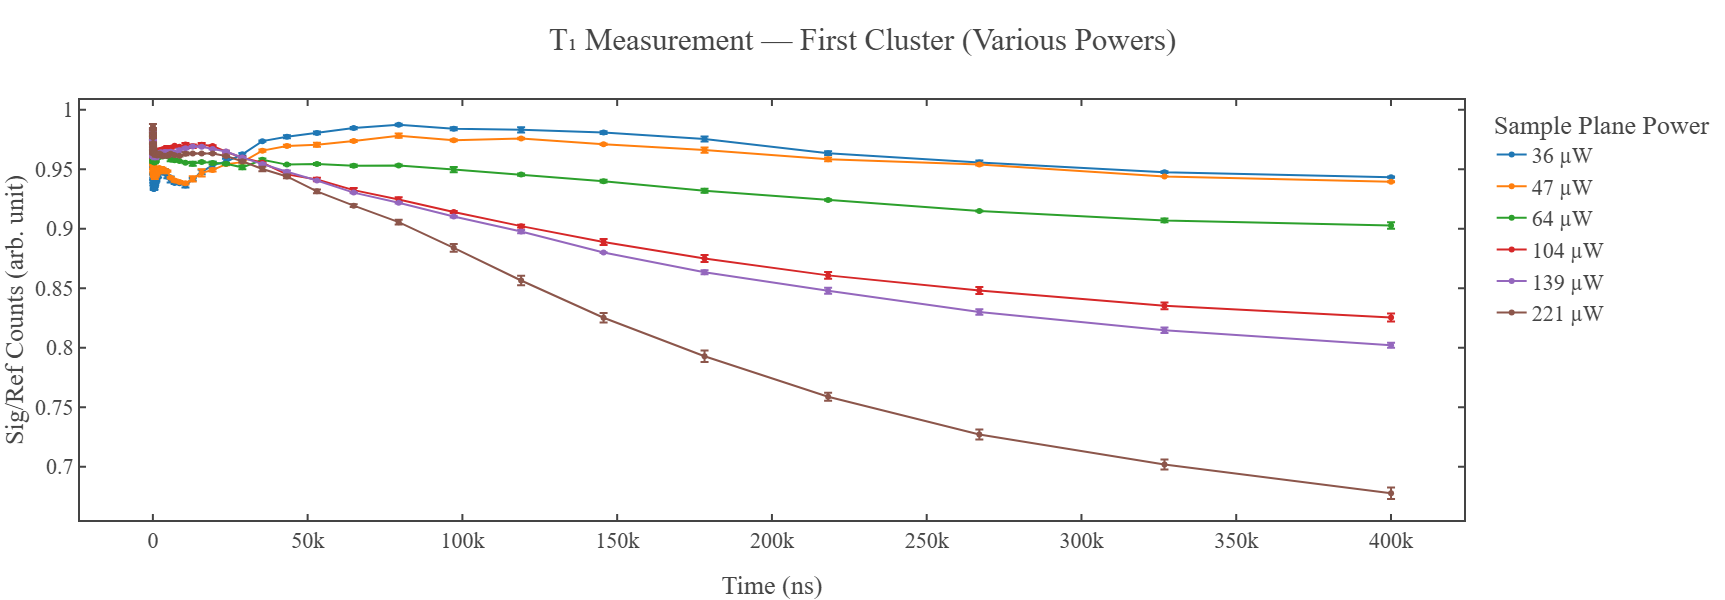

Plot saved to: C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10\first cluster\t1_plot_first_cluster_36uW_47uW_64uW_104uW_139uW_221uW.html


In [75]:
# --- Parameters ---
samples = 2000
base_path = r"C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10\first cluster"
pulse_folder = 'l_50.0us'
systematic_path = r"systematic\a_5\s_2000"

# --- Power folders to process ---
power_folders = ['p_3mW', 'p_4mW', 'p_5mW', 'p_9mW', 'p_11mW', 'p_18mW']

# --- Initialize figure ---
fig = go.Figure()

# --- Loop over power folders ---
for power_folder in power_folders:
    try:
        source_power_mW = int(power_folder.split('_')[1].replace('mW', ''))
    except (IndexError, ValueError):
        print(f"Could not parse power from folder: {power_folder}")
        continue

    sample_power_uW = calibration.get(source_power_mW, None)
    if sample_power_uW is None:
        print(f"[⚠️] No calibration for {source_power_mW} mW — Skipping.")
        continue

    folder_path = os.path.join(base_path, power_folder, pulse_folder, systematic_path)
    if not os.path.exists(folder_path):
        print(f"[❌] Folder not found: {folder_path}")
        continue

    npz_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.npz')])
    if len(npz_files) < 3:
        print(f"[⚠️] Less than 3 datasets in {folder_path}. Skipping.")
        continue

    signal_photon_list = []
    time_axis = None

    for npz_file in npz_files[:3]:
        npz_path = os.path.join(folder_path, npz_file)
        data = dict(np.load(npz_path))
        time_axis, signal_photon, _, _ = data_to_time_signal(data, samples, first='signal')
        signal_photon_list.append(signal_photon[1:])  # Skip first point

    signal_array = np.vstack(signal_photon_list)
    mean_signal = np.mean(signal_array, axis=0)
    std_signal = np.std(signal_array, axis=0)

    fig.add_trace(go.Scatter(
        x=time_axis[1:],  # Skip first point
        y=mean_signal,
        mode='markers+lines',
        name=f'{sample_power_uW} µW',
        error_y=dict(
            type='data',
            array=std_signal,
            visible=True
        )
    ))

# --- Final layout ---
fig.update_layout(
    template=fig_template,
    title='T₁ Measurement — First Cluster (Various Powers)',
    xaxis_title='Time (ns)',
    yaxis_title='Sig/Ref Counts (arb. unit)',
    legend_title='Sample Plane Power',
    height = 600,
    width = 800
)

# --- Show and Save ---
fig.show()

# --- Save as HTML ---
valid_powers = [
    f"{calibration[int(p.split('_')[1].replace('mW', ''))]}uW"
    for p in power_folders
    if int(p.split('_')[1].replace('mW', '')) in calibration
]

filename_suffix = "_".join(valid_powers)
output_path = os.path.join(base_path, f"t1_plot_first_cluster_{filename_suffix}.html")
fig.write_html(output_path)
print(f"Plot saved to: {output_path}")


Processing: 1 mol → small cluster


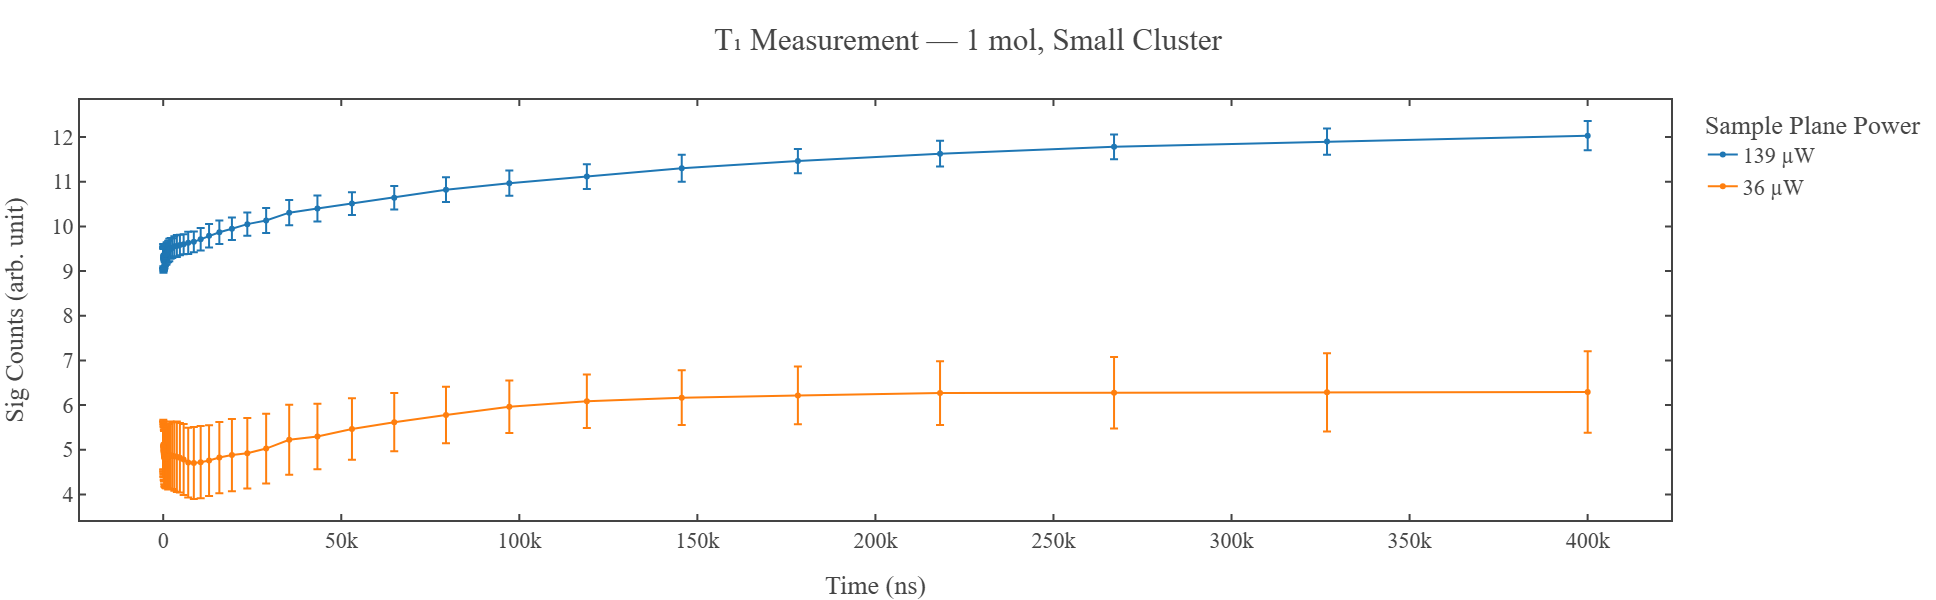

Saved: C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10\citric acid\1 mol\small cluster\t1_plot_1_mol_small_cluster_139uW_36uW_sig.html

Processing: 1 mol → big cluster


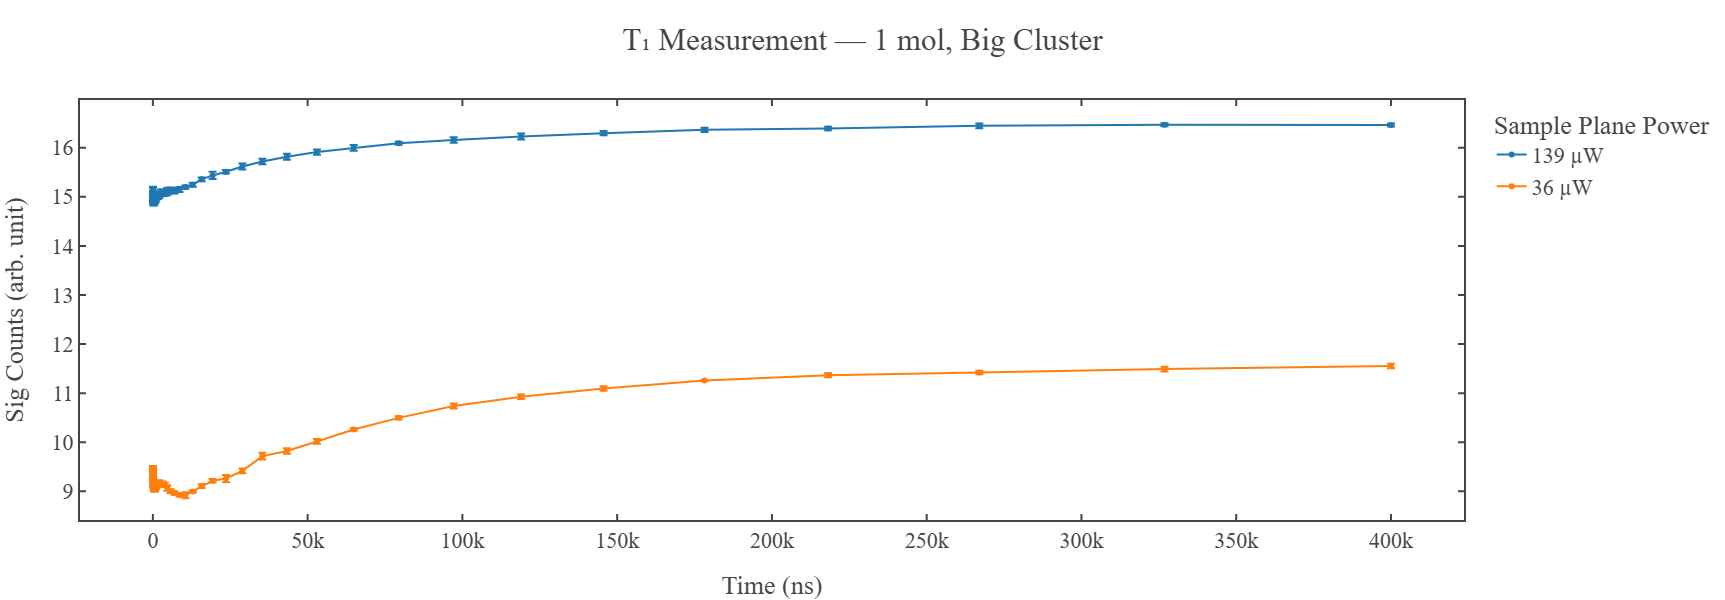

Saved: C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10\citric acid\1 mol\big cluster\t1_plot_1_mol_big_cluster_139uW_36uW_sig.html

Processing: 1 mol → bigger cluster


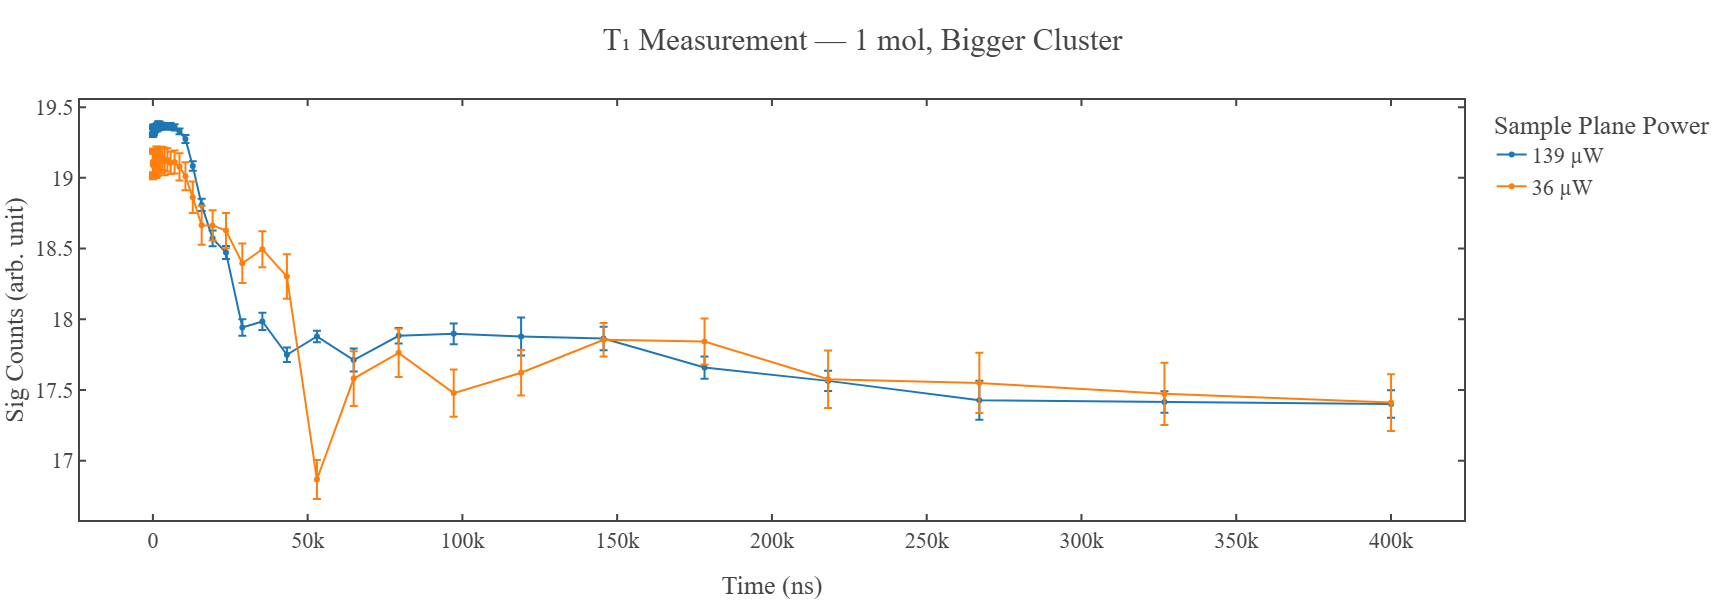

Saved: C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10\citric acid\1 mol\bigger cluster\t1_plot_1_mol_bigger_cluster_139uW_36uW_sig.html

Processing: 0.1 mol → small cluster


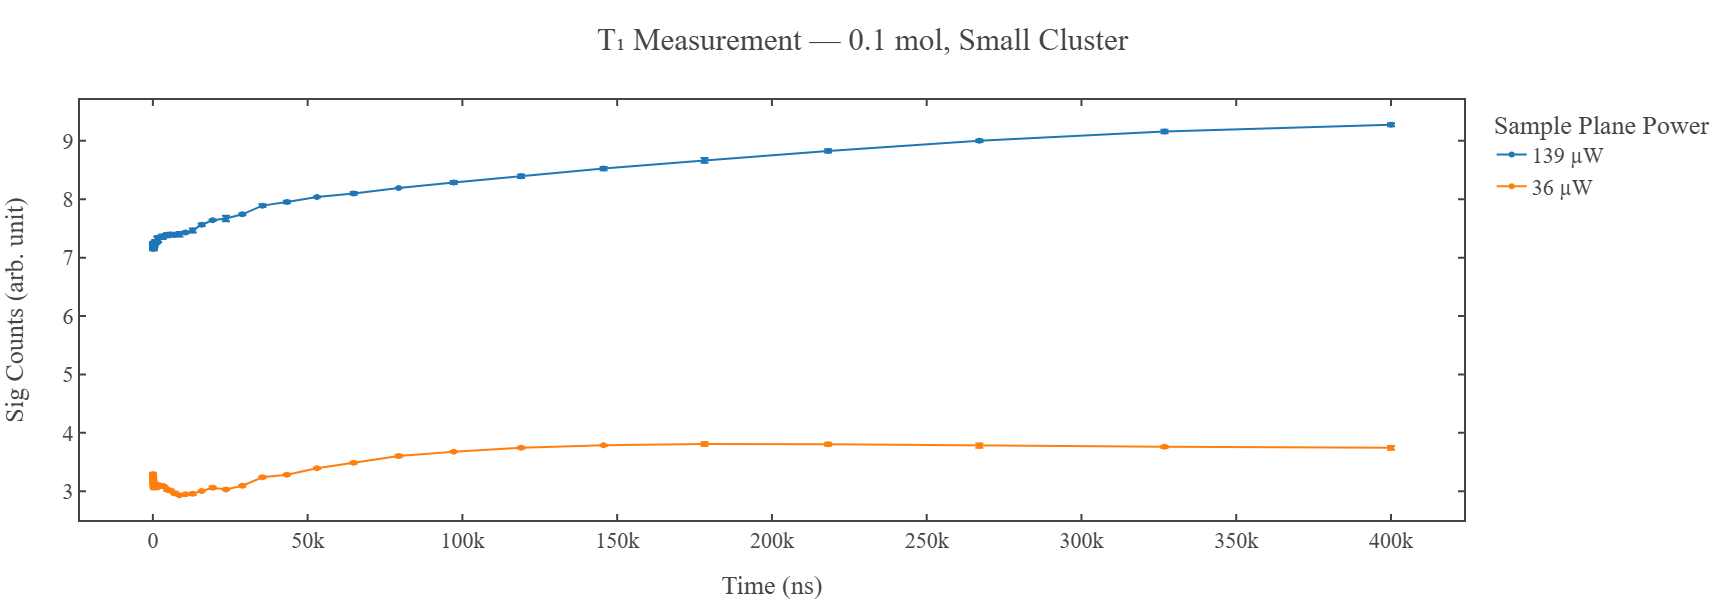

Saved: C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10\citric acid\0.1 mol\small cluster\t1_plot_0.1_mol_small_cluster_139uW_36uW_sig.html

Processing: 0.1 mol → big cluster


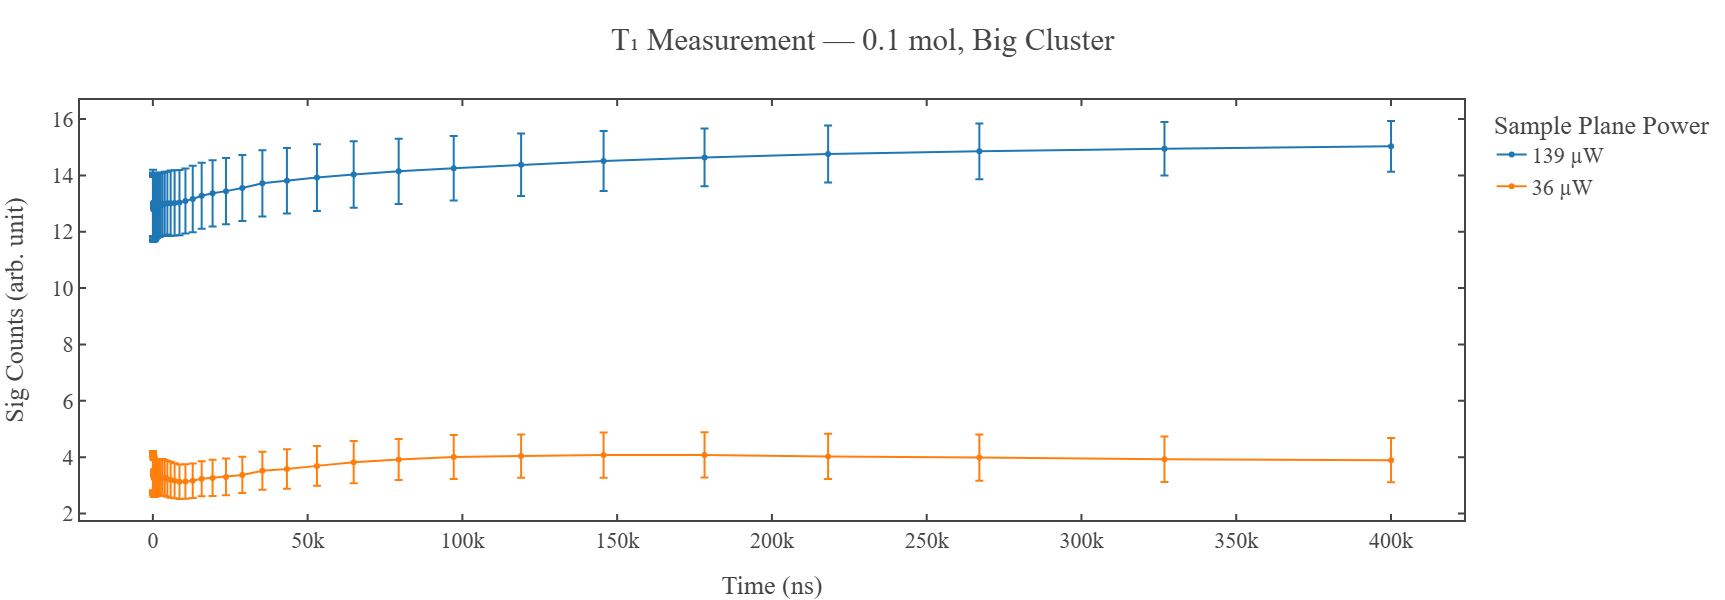

Saved: C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10\citric acid\0.1 mol\big cluster\t1_plot_0.1_mol_big_cluster_139uW_36uW_sig.html

Processing: 0.1 mol → bigger cluster


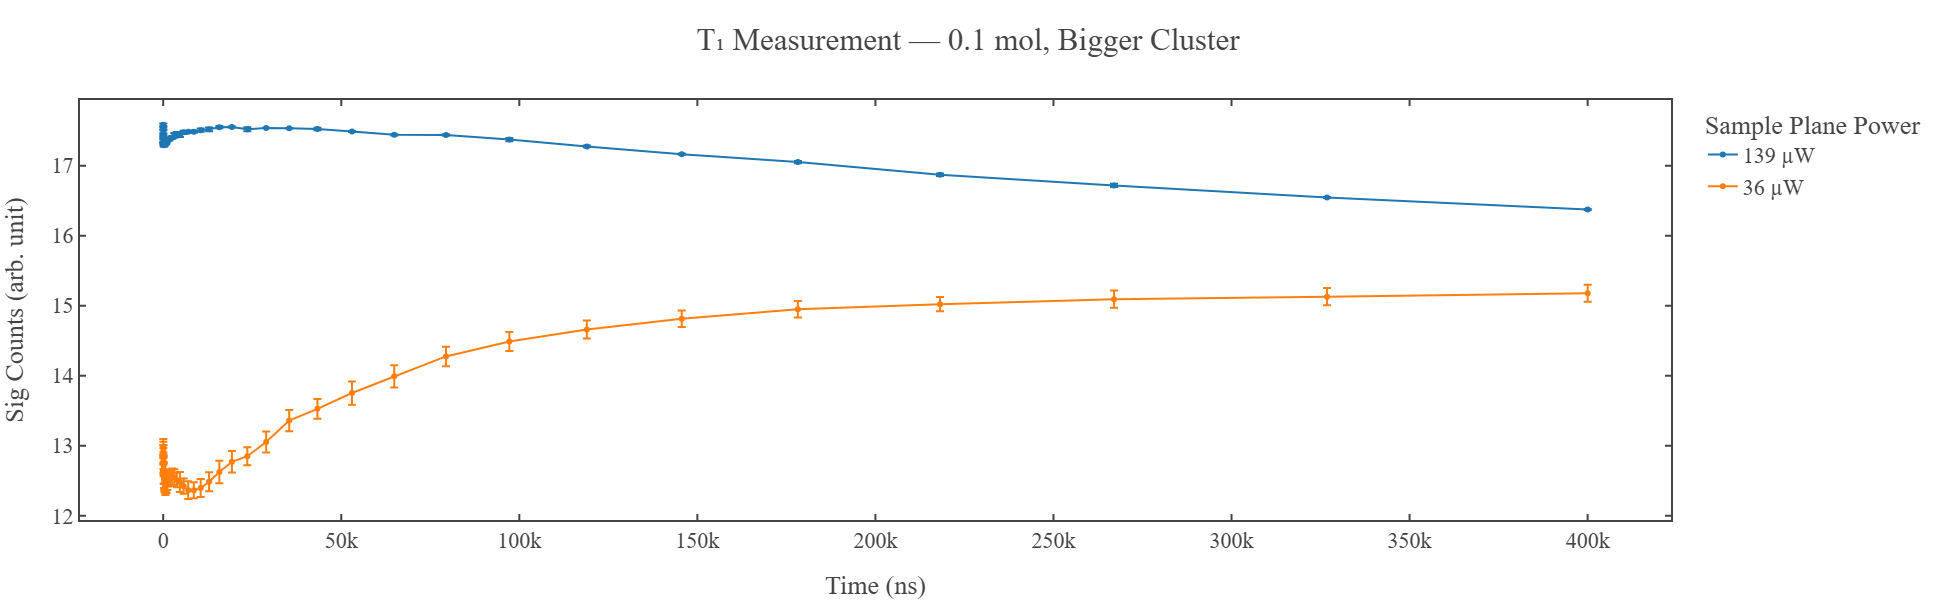

Saved: C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10\citric acid\0.1 mol\bigger cluster\t1_plot_0.1_mol_bigger_cluster_139uW_36uW_sig.html


In [55]:
# --- Parameters ---
samples = 2000
root_base = r"C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10\citric acid"
mol_levels = ['1 mol', '0.1 mol']
cluster_types = ['small cluster', 'big cluster', 'bigger cluster']
power_folders = ['p_11mW', 'p_3mW']
pulse_folder = 'l_50.0us'
systematic_path = r"systematic\a_5\s_2000"

# --- Loop through each molarity and cluster ---
for mol in mol_levels:
    for cluster in cluster_types:
        print(f"\nProcessing: {mol} → {cluster}")

        fig = go.Figure()

        for power_folder in power_folders:
            try:
                source_power_mW = int(power_folder.split('_')[1].replace('mW', ''))
            except (IndexError, ValueError):
                print(f"Could not extract power from: {power_folder}")
                continue

            sample_power_uW = calibration.get(source_power_mW, None)
            if sample_power_uW is None:
                print(f"No calibration available for {source_power_mW} mW. Skipping.")
                continue

            # Build full path
            cluster_path = os.path.join(root_base, mol, cluster)
            data_path = os.path.join(cluster_path, power_folder, pulse_folder, systematic_path)

            if not os.path.exists(data_path):
                print(f"Path not found: {data_path}")
                continue

            # Load .npz files
            npz_files = sorted([f for f in os.listdir(data_path) if f.endswith('.npz')])
            if len(npz_files) < 3:
                print(f"Less than 3 datasets found in {data_path}. Skipping.")
                continue

            signal_photon_list = []
            time_axis = None

            for npz_file in npz_files[:3]:
                file_path = os.path.join(data_path, npz_file)
                data = dict(np.load(file_path))
                time_axis, signal_photon, _, _ = data_to_time_signal(data, samples, first='signal')
                signal_photon_list.append(signal_photon[1:])  # Skip first point

            signal_array = np.vstack(signal_photon_list)
            mean_signal = np.mean(signal_array, axis=0)
            std_signal = np.std(signal_array, axis=0)

            fig.add_trace(go.Scatter(
                x=time_axis[1:],  # Skip first point
                y=mean_signal,
                mode='markers+lines',
                name=f'{sample_power_uW} µW',
                error_y=dict(
                    type='data',
                    array=std_signal,
                    visible=True
                )
            ))

        # Final layout
        fig.update_layout(
            template=fig_template,
            title=f"T₁ Measurement — {mol}, {cluster.title()}",
            xaxis_title='Time (ns)',
            yaxis_title='Sig/Ref Counts (arb. unit)',
            legend_title='Sample Plane Power',
            height = 600,
            width = 800,
        )

        fig.show()

        # Save
        filename_suffix = "_".join([
            f"{calibration[int(p.split('_')[1].replace('mW', ''))]}uW"
            for p in power_folders
            if int(p.split('_')[1].replace('mW', '')) in calibration
        ])
        safe_cluster = cluster.replace(" ", "_").lower()
        safe_mol = mol.replace(" ", "_").lower()
        output_path = os.path.join(cluster_path, f"t1_plot_{safe_mol}_{safe_cluster}_{filename_suffix}.html")
        fig.write_html(output_path)
        print(f"Saved: {output_path}")

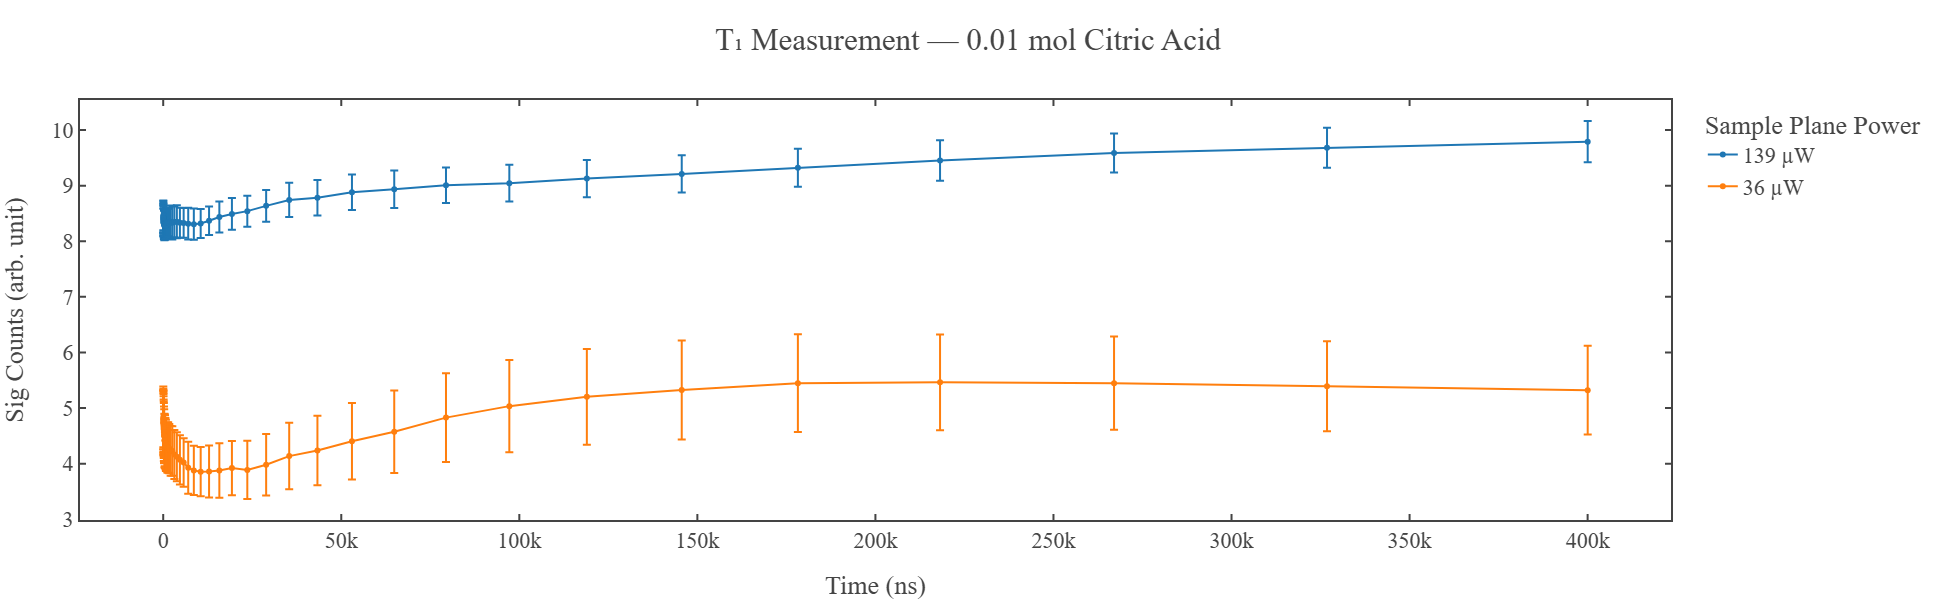

Plot saved to: C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10\citric acid\0.01 mol\t1_plot_0.01mol_139uW_36uW_sig.html


In [59]:
# --- Parameters ---
samples = 2000
base_path = r"C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10\citric acid\0.01 mol"
power_folders = ['p_11mW', 'p_3mW']
pulse_folder = 'l_50.0us'
systematic_path = r"systematic\a_5\s_2000"

# --- Initialize Plot ---
fig = go.Figure()

# --- Process each power ---
for power_folder in power_folders:
    try:
        source_power_mW = int(power_folder.split('_')[1].replace('mW', ''))
    except (IndexError, ValueError):
        print(f"Could not extract power from: {power_folder}")
        continue

    sample_power_uW = calibration.get(source_power_mW, None)
    if sample_power_uW is None:
        print(f"No calibration available for {source_power_mW} mW. Skipping.")
        continue

    folder_path = os.path.join(base_path, power_folder, pulse_folder, systematic_path)
    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        continue

    npz_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.npz')])
    if len(npz_files) < 3:
        print(f"Less than 3 datasets found in {folder_path}. Skipping.")
        continue

    signal_photon_list = []
    time_axis = None

    for npz_file in npz_files[:3]:
        npz_path = os.path.join(folder_path, npz_file)
        data = dict(np.load(npz_path))
        time_axis, signal_photon, _, _ = data_to_time_signal(data, samples, first='signal')
        signal_photon_list.append(signal_photon[1:])  # Skip first point

    signal_array = np.vstack(signal_photon_list)
    mean_signal = np.mean(signal_array, axis=0)
    std_signal = np.std(signal_array, axis=0)

    fig.add_trace(go.Scatter(
        x=time_axis[1:],
        y=mean_signal,
        mode='markers+lines',
        name=f'{sample_power_uW} µW',
        error_y=dict(
            type='data',
            array=std_signal,
            visible=True
        )
    ))

# --- Final Layout ---
fig.update_layout(
    template=fig_template,
    title='T₁ Measurement — 0.01 mol Citric Acid',
    xaxis_title='Time (ns)',
    yaxis_title='Sig/Ref Counts (arb. unit)',
    legend_title='Sample Plane Power',
    height = 600,
    width = 800,
)

# --- Show and Save ---
fig.show()

# Save plot
filename_suffix = "_".join([
    f"{calibration[int(p.split('_')[1].replace('mW', ''))]}uW"
    for p in power_folders
    if int(p.split('_')[1].replace('mW', '')) in calibration
])
output_path = os.path.join(base_path, f"t1_plot_0.01mol_{filename_suffix}.html")
fig.write_html(output_path)
print(f"Plot saved to: {output_path}")